# Proyecto 1 — Análisis de remesas en Guatemala
Alina Carías 22539 - Marcos Díaz 221102 - Ignacio Méndez 22613

## Objetivo
Entender cómo han cambiado las remesas a Guatemala a lo largo del tiempo, si existe estacionalidad y si en 2026 aparece alguna señal distinta después de la entrada del impuesto del 1% en Estados Unidos.

## 1. Librerías y configuración


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import skew

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

## 2. Carga de datos

Trabajo con dos archivos: uno contiene los montos mensuales de remesas y el otro las variaciones reportadas. Ambos archivos presentaban una estructura que incluía títulos, notas aclaratorias y otros elementos de formato, mientras que las columnas correspondientes a los datos se encontraban distribuidas en diferentes hojas y ubicadas en la parte central de cada archivo. Con el objetivo de facilitar el procesamiento y análisis, se internivo manualmente en los datos, mediante la selección y copia de las columnas relevantes hacia nuevos archivos de Excel. Por último, se cargaron para revisar cómo vienen estructurados.


In [35]:
ingresos_raw = pd.read_excel("Ingresos Remesas 2002-2026.xlsx", sheet_name="Hoja1")
variaciones_raw = pd.read_excel("Remesas Variaciones 2011-2026.xlsx", sheet_name="Hoja1")

print("INGRESOS (crudo) ---")
display(ingresos_raw.head(15))

print("\nVARIACIONES (crudo) ---")
display(variaciones_raw.head(15))

INGRESOS (crudo) ---


,Mes,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
0,Enero,83.155736,164.756552,194.744017,209.450403,248.903903,287.100918,314.606698,290.240344,246.129315,283.348134,305.090512,357.872166,394.193087,407.433942,481.961382,587.634116,634.581836,688.076393,834.610433,906.804848,1180.744400,1386.491933,1468.027106,1817.555020,1954.707294
1,Febrero,96.659390,144.743414,183.738858,203.787038,254.794536,271.944096,318.306970,281.951384,274.512700,304.621236,350.387387,351.169081,383.939661,431.979861,558.037868,613.901532,630.102698,690.499485,808.025353,942.896614,1262.672152,1381.094219,1527.940225,1821.358873,1893.869963
2,Marzo,109.033736,160.778107,227.895447,246.466058,288.966241,327.639219,340.459481,344.145577,369.953284,384.120374,402.127565,424.053233,459.229117,556.476492,622.985518,739.816956,754.485147,826.713725,746.784665,1285.560214,1493.138978,1665.832555,1686.629669,2003.741116,2441.799547
3,Abril,139.211991,181.087331,204.013193,253.086944,284.440175,333.625051,385.252437,339.687309,344.408915,371.286603,418.968111,451.241220,490.683178,503.848903,609.311804,639.881207,769.947356,865.156773,690.769066,1231.691196,1516.102072,1551.369164,1848.057808,1984.607646,2141.177339
4,Mayo,89.751735,187.376335,210.780391,274.281236,361.391081,392.936459,397.982879,332.603333,357.017198,415.324708,451.558012,476.990317,494.058750,518.952845,625.300361,747.425886,808.546264,974.465955,836.760956,1236.685496,1592.507594,1811.863789,1980.078629,2281.079404,2221.436714
5,Junio,127.976322,161.494571,212.129767,261.104397,310.096620,356.473114,384.331786,348.577798,394.289715,416.388448,432.674847,417.195055,481.857138,536.302692,614.661858,723.705778,801.419337,882.017378,963.299028,1362.511245,1666.224974,1861.327269,1760.625865,2219.312347,2325.540615
6,Julio,136.525367,191.954330,206.612929,245.807246,302.884908,381.151779,409.667135,365.551030,384.612420,349.829452,422.088834,445.758425,509.730095,573.714508,536.124734,664.187529,818.349007,947.829241,1078.722257,1354.327581,1370.027871,1642.851042,1819.004690,2366.035089,2468.590521
7,Agosto,162.307899,178.913196,212.781741,241.923935,332.942140,381.410679,373.536235,337.449407,377.358286,409.558406,441.401166,456.338728,476.792770,527.340132,619.225404,707.841627,860.427256,980.570467,1050.161136,1388.590892,1642.651290,1773.350572,2020.551747,2368.014649,NaN
8,Septiembre,157.338773,176.550967,211.777249,241.583545,293.005045,326.751228,371.835978,332.103670,359.310465,364.782674,365.797796,420.684341,458.776313,538.353092,607.665225,672.939407,745.975030,892.293490,1051.254836,1299.324903,1597.206358,1699.459758,1724.072018,2106.689854,NaN
9,Octubre,176.260812,189.880921,218.026592,278.150481,338.406610,391.169883,367.727740,327.523114,339.374063,356.804604,415.446523,480.044294,500.533052,583.763652,605.940385,728.273021,863.521377,999.957415,1132.959441,1418.502355,1622.432849,1650.734715,2000.411591,2389.972331,NaN



VARIACIONES (crudo) ---


,Mes,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
0,Enero,15.121652,7.673380,17.300326,10.149132,3.358977,18.291908,21.925560,7.989277,8.429891,21.296188,8.650073,30.209317,17.425239,5.880681,23.809364,7.545976
1,Febrero,12.931602,11.481640,8.171648,9.744356,7.875399,23.895896,15.532357,5.255681,9.005514,19.154543,12.605696,32.097887,13.267062,8.251999,21.460400,5.761702
2,Marzo,9.150559,8.797101,7.137729,9.202003,12.811808,19.134346,16.739049,4.008395,9.217646,8.349509,31.214315,25.557479,12.621775,5.620455,20.502683,11.479025
3,Abril,8.775042,9.915109,7.298121,9.070637,9.935745,19.610975,13.595815,8.053638,10.086681,0.317320,41.775461,24.861838,9.759099,9.120907,16.791698,10.544956
4,Mayo,10.469686,9.633845,6.907953,7.799726,8.846943,19.800160,14.876561,8.081439,12.431653,-3.163526,43.061252,25.724837,10.666698,9.158826,16.421718,7.515372
5,Junio,9.503968,8.538358,4.986205,9.095741,9.283929,18.858377,15.377759,8.555920,11.999026,-0.947450,42.741669,25.053159,10.866104,6.351022,18.072536,7.016007
6,Julio,6.495166,10.217212,5.080472,9.896849,9.802380,14.727036,16.504599,10.619591,12.598676,1.433468,39.629411,21.163941,12.095639,6.986514,19.878024,6.578259
7,Agosto,6.774979,9.876344,4.848245,9.165944,9.905628,15.077715,16.213563,12.046769,12.791849,2.243561,38.520245,20.753807,11.515722,7.929638,19.494046,NaN
8,Septiembre,6.167725,8.815134,5.883086,9.153640,10.728235,14.819592,15.583264,11.915042,13.537683,4.036913,36.573988,21.010176,10.902594,7.184062,19.787867,NaN
9,Octubre,6.066154,9.558806,6.885615,8.605850,11.363365,13.577170,16.057780,12.625225,13.791804,5.095887,35.172697,20.252952,9.908293,8.591038,19.752667,NaN


## 3. Limpieza y preparación

Dentro de los archivos cada año está en una columna diferente. Para analizar la serie de tiempo es más práctico tener una fila por mes, se convierten los datos a formato largo y se contuye una fecha real.


### 3.1 Ingresos mensuales


In [36]:
# Quitar fila Total
ingresos = ingresos_raw[ingresos_raw["Mes"] != "Total"].copy()

# Wide -> Long
ingresos_long = ingresos.melt(id_vars="Mes", var_name="anio", value_name="monto_millones_usd")
ingresos_long["anio"] = ingresos_long["anio"].astype(int)

In [37]:
# Mapeo de mes en español -> número de mes
meses_map = {
    "Enero": 1, "Febrero": 2, "Marzo": 3, "Abril": 4,
    "Mayo": 5, "Junio": 6, "Julio": 7, "Agosto": 8,
    "Septiembre": 9, "Octubre": 10, "Noviembre": 11, "Diciembre": 12
}
ingresos_long["mes_num"] = ingresos_long["Mes"].map(meses_map)

# Quitar meses futuros sin dato 
ingresos_long = ingresos_long.dropna(subset=["monto_millones_usd"]).copy()

In [38]:
# Construir columna de fecha real (día 1 de cada mes)
ingresos_long["fecha"] = pd.to_datetime(
    dict(year=ingresos_long["anio"], month=ingresos_long["mes_num"], day=1)
)

ingresos_long = ingresos_long.rename(columns={"Mes": "mes_nombre"})
ingresos_long = ingresos_long.sort_values("fecha").reset_index(drop=True)
ingresos_long = ingresos_long[["fecha", "anio", "mes_num", "mes_nombre", "monto_millones_usd"]]

print(f"Rango: {ingresos_long['fecha'].min().date()} → {ingresos_long['fecha'].max().date()}")
print(f"Total de meses: {len(ingresos_long)}")
display(ingresos_long.head())
display(ingresos_long.tail())

Rango: 2002-01-01 → 2026-07-01
Total de meses: 295


,fecha,anio,mes_num,mes_nombre,monto_millones_usd
0,2002-01-01,2002,1,Enero,83.155736
1,2002-02-01,2002,2,Febrero,96.659390
2,2002-03-01,2002,3,Marzo,109.033736
3,2002-04-01,2002,4,Abril,139.211991
4,2002-05-01,2002,5,Mayo,89.751735


,fecha,anio,mes_num,mes_nombre,monto_millones_usd
290,2026-03-01,2026,3,Marzo,2441.799547
291,2026-04-01,2026,4,Abril,2141.177339
292,2026-05-01,2026,5,Mayo,2221.436714
293,2026-06-01,2026,6,Junio,2325.540615
294,2026-07-01,2026,7,Julio,2468.590521


### 3.2 Variaciones


In [39]:
variaciones = variaciones_raw.copy()

variaciones_long = variaciones.melt(id_vars="Mes", var_name="anio", value_name="variacion_pct")
variaciones_long["anio"] = variaciones_long["anio"].astype(int)
variaciones_long["mes_num"] = variaciones_long["Mes"].map(meses_map)
variaciones_long = variaciones_long.dropna(subset=["variacion_pct"]).copy()

variaciones_long["fecha"] = pd.to_datetime(
    dict(year=variaciones_long["anio"], month=variaciones_long["mes_num"], day=1)
)

In [40]:
variaciones_long = variaciones_long.rename(columns={"Mes": "mes_nombre"})
variaciones_long = variaciones_long.sort_values("fecha").reset_index(drop=True)
variaciones_long = variaciones_long[["fecha", "anio", "mes_num", "mes_nombre", "variacion_pct"]]

print(f"Rango: {variaciones_long['fecha'].min().date()} → {variaciones_long['fecha'].max().date()}")
display(variaciones_long.head())

Rango: 2011-01-01 → 2026-07-01


,fecha,anio,mes_num,mes_nombre,variacion_pct
0,2011-01-01,2011,1,Enero,15.121652
1,2011-02-01,2011,2,Febrero,12.931602
2,2011-03-01,2011,3,Marzo,9.150559
3,2011-04-01,2011,4,Abril,8.775042
4,2011-05-01,2011,5,Mayo,10.469686


## 4. Revisión de calidad de datos

Antes de graficar se verifican tres cosas básicas: valores nulos, fechas duplicadas y huecos en la secuencia mensual. Esto ayuda a asegurar que los patrones que aparezcan después no sean un problema de la limpieza.


In [41]:
print("--- Nulos ---")      
print(ingresos_long.isnull().sum())

--- Nulos ---
fecha                 0
anio                  0
mes_num               0
mes_nombre            0
monto_millones_usd    0
dtype: int64


In [42]:
print("\n--- Duplicados en fecha ---")
print(ingresos_long["fecha"].duplicated().sum())


--- Duplicados en fecha ---
0


In [43]:
print("\n--- ¿Meses consecutivos sin huecos? ---")
rango_completo = pd.date_range(ingresos_long["fecha"].min(), ingresos_long["fecha"].max(), freq="MS")
faltantes = set(rango_completo) - set(ingresos_long["fecha"])
print(f"Meses faltantes dentro del rango: {sorted(faltantes)}")


--- ¿Meses consecutivos sin huecos? ---
Meses faltantes dentro del rango: []


In [44]:
print("\n--- Estadísticas descriptivas del monto mensual ---")
display(ingresos_long["monto_millones_usd"].describe())


--- Estadísticas descriptivas del monto mensual ---


count     295.000000
mean      737.398688
std       599.719018
min        83.155736
25%       329.511911
50%       458.776313
75%       968.882491
max      2468.590521
Name: monto_millones_usd, dtype: float64

## 5. Distribución de los montos mensuales

Primero se observan la distribución para entender el rango de los montos y detectar posibles valores extremos. Se usa un **histograma** porque permite ver la forma de la distribución y un **boxplot** porque resume la mediana, dispersión y posibles outliers.

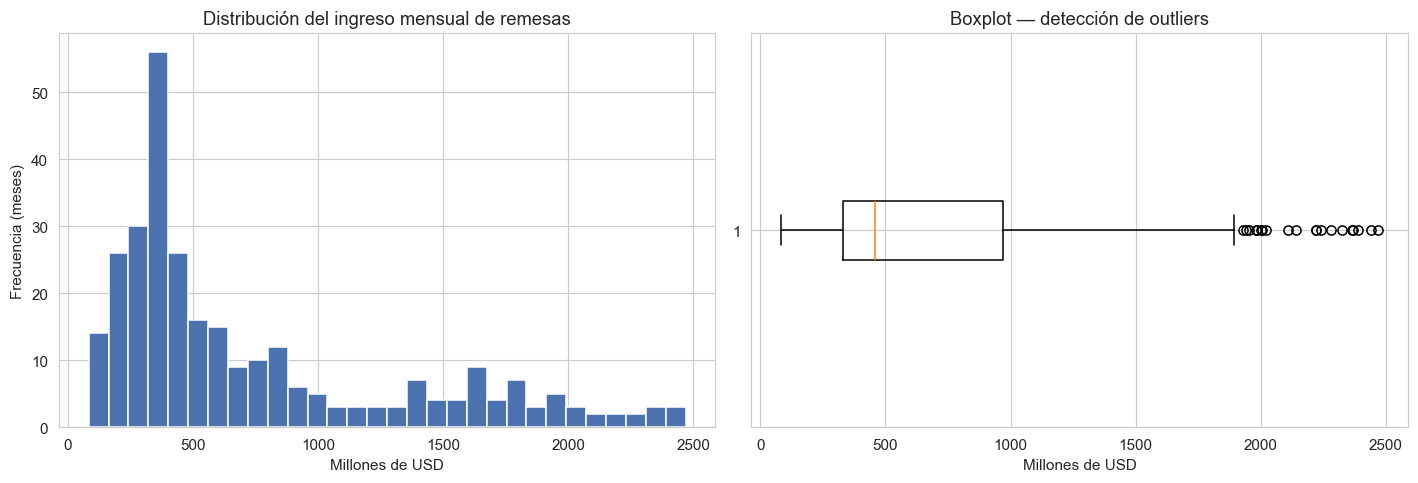

Skewness: 1.225
(0 = simétrica | >0 = cola a la derecha | <0 = cola a la izquierda)


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Histograma
axes[0].hist(ingresos_long["monto_millones_usd"], bins=30, color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribución del ingreso mensual de remesas")
axes[0].set_xlabel("Millones de USD")
axes[0].set_ylabel("Frecuencia (meses)")

# Boxplot para ver outliers de forma explícita
axes[1].boxplot(ingresos_long["monto_millones_usd"], vert=False)
axes[1].set_title("Boxplot — detección de outliers")
axes[1].set_xlabel("Millones de USD")

plt.tight_layout()
plt.show()

# Medidas de asimetría

print(f"Skewness: {skew(ingresos_long['monto_millones_usd']):.3f}")
print("(0 = simétrica | >0 = cola a la derecha | <0 = cola a la izquierda)")

El skewness positivo confirma que la distribución no es simétrica, ya que tiene una cola hacia la derecha. Los valores altos del boxplot deben interpretarse junto con la fecha, porque pueden reflejar el crecimiento de largo plazo de las remesas en lugar de observaciones con anómalias.

## 6. Evolución histórica de las remesas

Para datos temporales se usa una línea, porque la posición en el eje horizontal permite seguir el orden de los meses y ver con claridad la tendencia y las fluctuaciones.


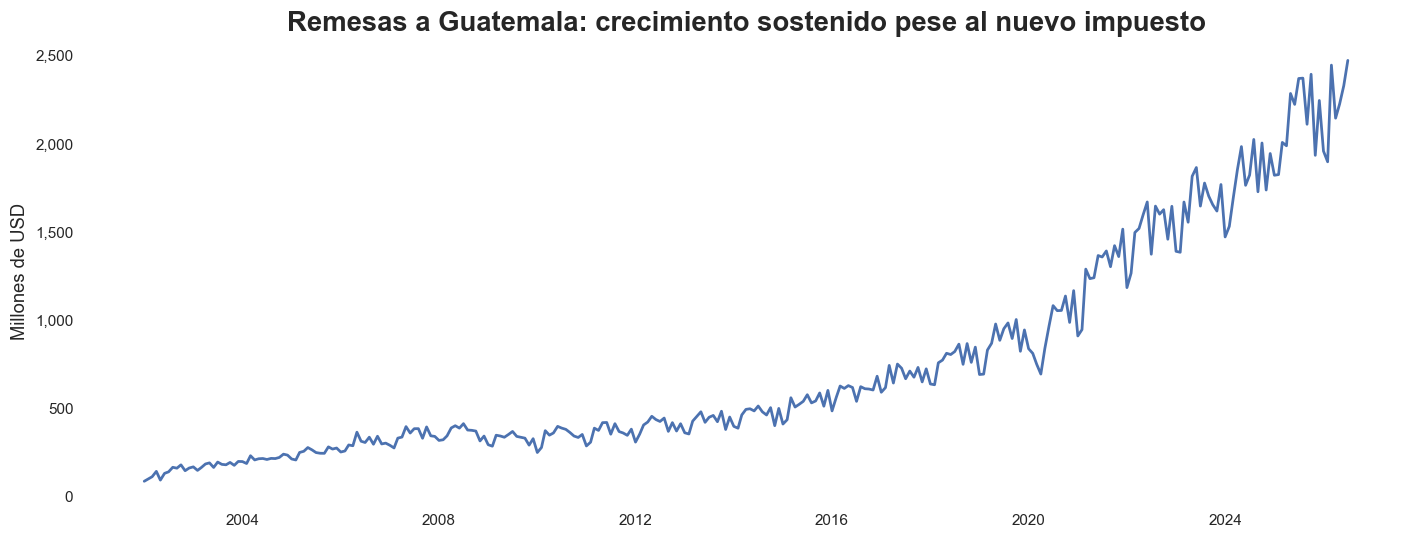

In [57]:
fig, ax = plt.subplots(figsize=(13, 5))


ax.plot(ingresos_long["fecha"], ingresos_long["monto_millones_usd"], 
        color="#4C72B0", linewidth=1.8)
ax.set_title("Remesas a Guatemala: crecimiento sostenido pese al nuevo impuesto", 
        fontsize=18, fontweight="bold", loc="center")

ax.set_xlabel("")
ax.set_ylabel("Millones de USD", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()

La dirección general es ascendente. Aunque existen meses con caídas, el nivel de remesas cambia de escala con el tiempo, especialmente a partir de la segunda mitad de la serie.


## 7. Crecimiento anual: ¿se acelera o se desacelera?

El monto total por sí solo siempre tiende a verse creciente, así que también se calcula la tasa de crecimiento contra el año anterior. Las barras funcionan bien aquí porque estoy comparando años discretos y permiten identificar rápidamente años fuertes, débiles o negativos.


In [58]:
anual = ingresos_long[ingresos_long["anio"] < 2026].groupby("anio")["monto_millones_usd"].sum().reset_index()
anual["crecimiento_pct"] = anual["monto_millones_usd"].pct_change() * 100

display(anual)

,anio,monto_millones_usd,crecimiento_pct
0,2002,1579.391877,NaN
1,2003,2106.504753,33.374420
2,2004,2550.623107,21.083188
3,2005,2992.822697,17.336924
4,2006,3609.813246,20.615673
5,2007,4128.407617,14.366238
6,2008,4314.730616,4.513193
7,2009,3912.286766,-9.327207
8,2010,4126.784067,5.482658
9,2011,4378.031960,6.088225


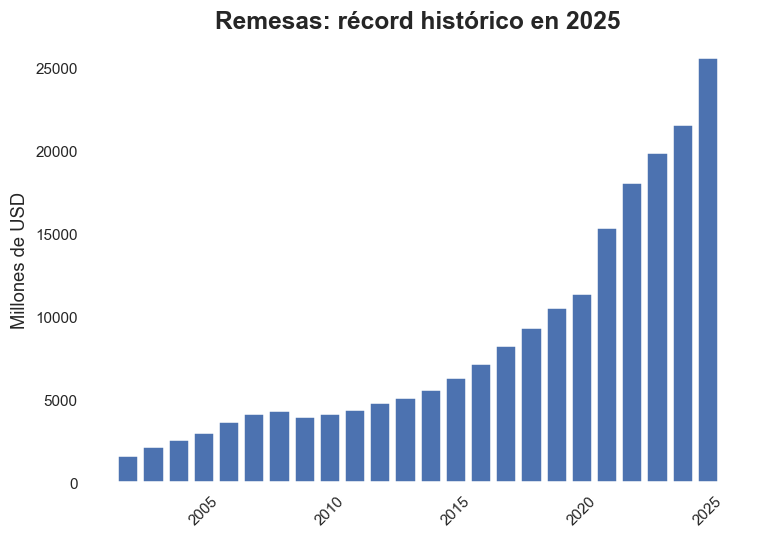

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(anual["anio"], anual["monto_millones_usd"], color="#4C72B0")
ax.set_title("Remesas: récord histórico en 2025", 
            fontsize=16, fontweight="bold", loc="center")

ax.set_ylabel("Millones de USD", fontsize=12)
ax.tick_params(axis='x', rotation=45)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()

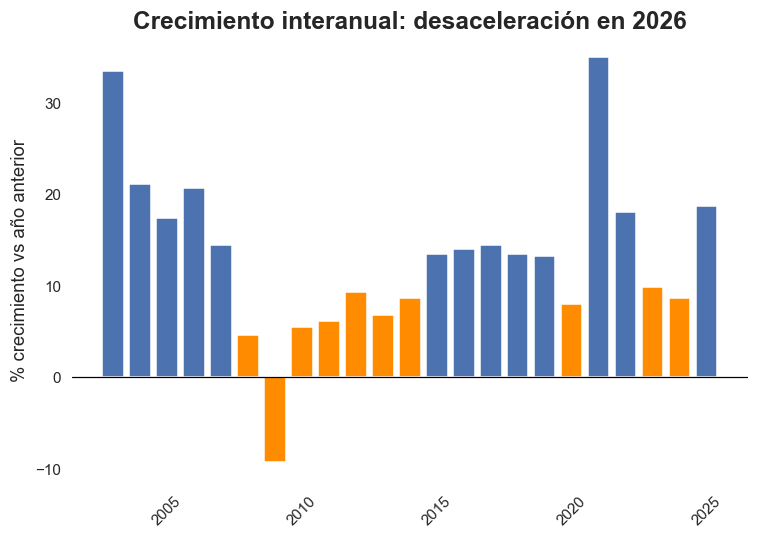

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

colors = ["#FF8C00" if v < 10 else "#4C72B0" for v in anual["crecimiento_pct"].fillna(0)]
ax.bar(anual["anio"], anual["crecimiento_pct"], color=colors)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Crecimiento interanual: desaceleración en 2026", 
            fontsize=16, fontweight="bold", loc="center")

ax.set_ylabel("% crecimiento vs año anterior", fontsize=12)
ax.tick_params(axis='x', rotation=45)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()

In [48]:
display(anual[["anio", "monto_millones_usd", "crecimiento_pct"]].round(2))

print("\n--- Top 3 años de mayor crecimiento ---")
display(anual.nlargest(3, "crecimiento_pct")[["anio", "crecimiento_pct"]])

print("\n--- Promedio de crecimiento por sub-período ---")
periodos = {
    "2003-2007 (pre-crisis)": (2003, 2007),
    "2008-2013 (crisis + recuperación lenta)": (2008, 2013),
    "2014-2019 (estabilización)": (2014, 2019),
    "2020-2021 (pandemia + rebote)": (2020, 2021),
    "2022-2025 (post-pandemia)": (2022, 2025),
}
for nombre, (ini, fin) in periodos.items():
    sub = anual[(anual["anio"] >= ini) & (anual["anio"] <= fin)]
    print(f"{nombre}: {sub['crecimiento_pct'].mean():.1f}% promedio")

,anio,monto_millones_usd,crecimiento_pct
0,2002,1579.39,NaN
1,2003,2106.50,33.37
2,2004,2550.62,21.08
3,2005,2992.82,17.34
4,2006,3609.81,20.62
5,2007,4128.41,14.37
6,2008,4314.73,4.51
7,2009,3912.29,-9.33
8,2010,4126.78,5.48
9,2011,4378.03,6.09



--- Top 3 años de mayor crecimiento ---


,anio,crecimiento_pct
19,2021,34.877643
1,2003,33.374420
2,2004,21.083188



--- Promedio de crecimiento por sub-período ---
2003-2007 (pre-crisis): 21.4% promedio
2008-2013 (crisis + recuperación lenta): 3.8% promedio
2014-2019 (estabilización): 12.8% promedio
2020-2021 (pandemia + rebote): 21.4% promedio
2022-2025 (post-pandemia): 13.8% promedio


El crecimiento de las remesas no ha sido constante. Hay periodos de expansión fuerte, una caída en 2009 y un salto especialmente grande en 2021. En años recientes el mercado sigue creciendo, pero la tasa cambia bastante de un año a otro.


## 8. Un periodo atípico: pandemia y rebote

Para no perder el evento de la pandemia dentro de toda la serie, se separarán los años 2018–2022. Se mantiene la línea para observar la secuencia mensual y se sombrea únicamente para dirigir la atención al periodo de pandemia y al rebote posterior.


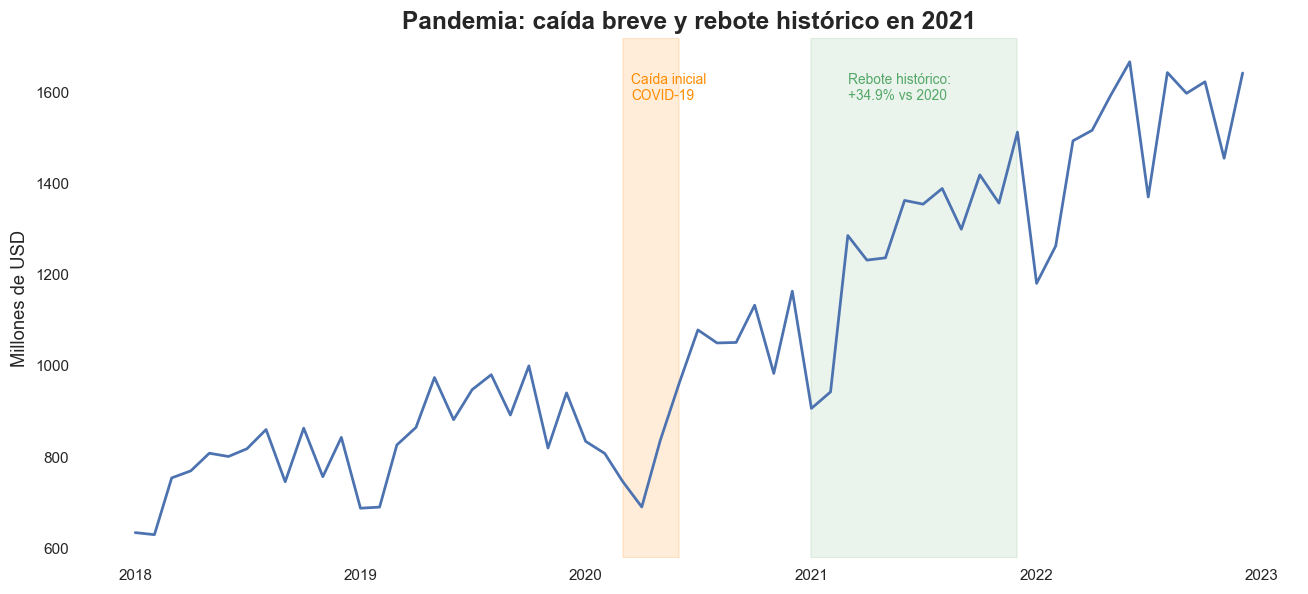

In [ ]:
evento = ingresos_long[(ingresos_long["anio"] >= 2018) & (ingresos_long["anio"] <= 2022)].copy()
fig, ax = plt.subplots(figsize=(12, 5.5))

ax.plot(evento["fecha"], evento["monto_millones_usd"], 
        color="#4C72B0", linewidth=1.8)
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2020-06-01"), 
        color="#FF8C00", alpha=0.15)
ax.text(pd.Timestamp("2020-03-15"), evento["monto_millones_usd"].max()*0.95, 
        "Caída inicial\nCOVID-19", color="#FF8C00", fontsize=9)
ax.axvspan(pd.Timestamp("2021-01-01"), pd.Timestamp("2021-12-01"), 
        color="#55A868", alpha=0.12)
ax.text(pd.Timestamp("2021-03-01"), evento["monto_millones_usd"].max()*0.95, 
        "Rebote histórico:\n+34.9% vs 2020", color="#55A868", fontsize=9)

ax.set_title("Pandemia: caída breve y rebote histórico en 2021", 
        fontsize=16, fontweight="bold", loc="center")
ax.set_ylabel("Millones de USD", fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()


La pandemia produjo una interrupción visible a corto plazo, pero no cambió la tendencia de fondo. En 2021 el crecimiento anual fue de aproximadamente **34.9%**, el mayor de la serie analizada.


## 9. Estacionalidad: meses fuertes y débiles

Después de la tendencia, se revisa si el mes del año realmente importa. Se promedia cada mes entre 2002 y 2025 para comparar meses equivalentes. 

In [50]:
estacional = (
    ingresos_long[ingresos_long["anio"] <= 2025]
    .groupby(["mes_num", "mes_nombre"], as_index=False)["monto_millones_usd"]
    .mean()
)

estacional

,mes_num,mes_nombre,monto_millones_usd
0,1,Enero,573.896383
1,2,Febrero,587.044360
2,3,Marzo,686.126353
3,4,Abril,683.655644
4,5,Mayo,743.988317
5,6,Junio,737.333223
6,7,Julio,730.139479
7,8,Agosto,763.393323
8,9,Septiembre,708.980501
9,10,Octubre,765.659076


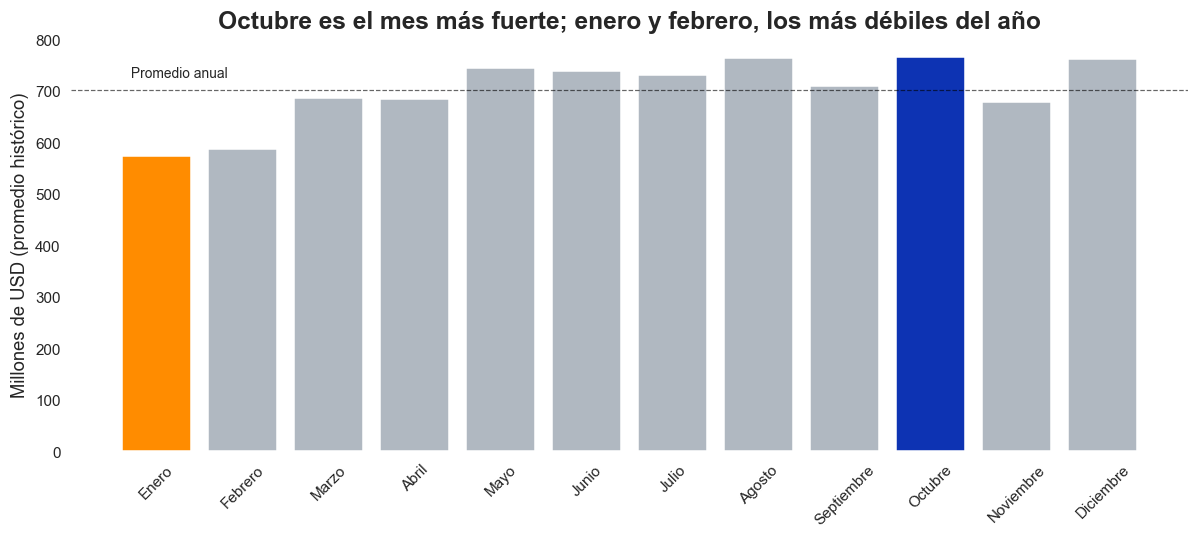

Diferencia Octubre vs Enero: 192M USD (33.4% más)


In [ ]:
estacional_sorted = estacional.sort_values("mes_num").copy()
promedio_general = estacional_sorted["monto_millones_usd"].mean()

colors_estacional = []
for v in estacional_sorted["monto_millones_usd"]:
    if v == estacional_sorted["monto_millones_usd"].max():
        colors_estacional.append("#0D33B3")   # mes más fuerte
    elif v == estacional_sorted["monto_millones_usd"].min():
        colors_estacional.append("#FF8C00")   # mes más débil (naranja)
    else:
        colors_estacional.append("#B0B8C1")   # resto en gris neutro

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(estacional_sorted["mes_nombre"], estacional_sorted["monto_millones_usd"], 
    color=colors_estacional)

# Línea de promedio
ax.axhline(promedio_general, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
ax.text(-0.3, promedio_general+20, "Promedio anual", 
        fontsize=9, ha="left", va="bottom")

ax.set_title("Octubre es el mes más fuerte; enero y febrero, los más débiles del año", 
            fontsize=16, fontweight="bold", loc="center")
ax.set_ylabel("Millones de USD (promedio histórico)", fontsize=12)
plt.xticks(rotation=45)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()

print(f"Diferencia Octubre vs Enero: {estacional_sorted['monto_millones_usd'].max() - estacional_sorted['monto_millones_usd'].min():.0f}M USD ({(estacional_sorted['monto_millones_usd'].max()/estacional_sorted['monto_millones_usd'].min()-1)*100:.1f}% más)")


Octubre tiene el promedio histórico más alto y enero el más bajo. La diferencia es cercana a **US$192 millones**, alrededor de **33%**. Esto quiere decir que la empresa puede anticipar mayor demanda en los meses históricamente fuertes y ajustar campañas o capacidad operativa.

## 10. Enfoque en 2026

Con el patrón histórico claro, ahora la investigación se centra en los años en 2023–2026. En enero de 2026 coincide con la entrada del impuesto del 1% en Estados Unidos. Esta gráfica sirve para buscar una ruptura visual, pero por sí sola no demuestra causalidad.


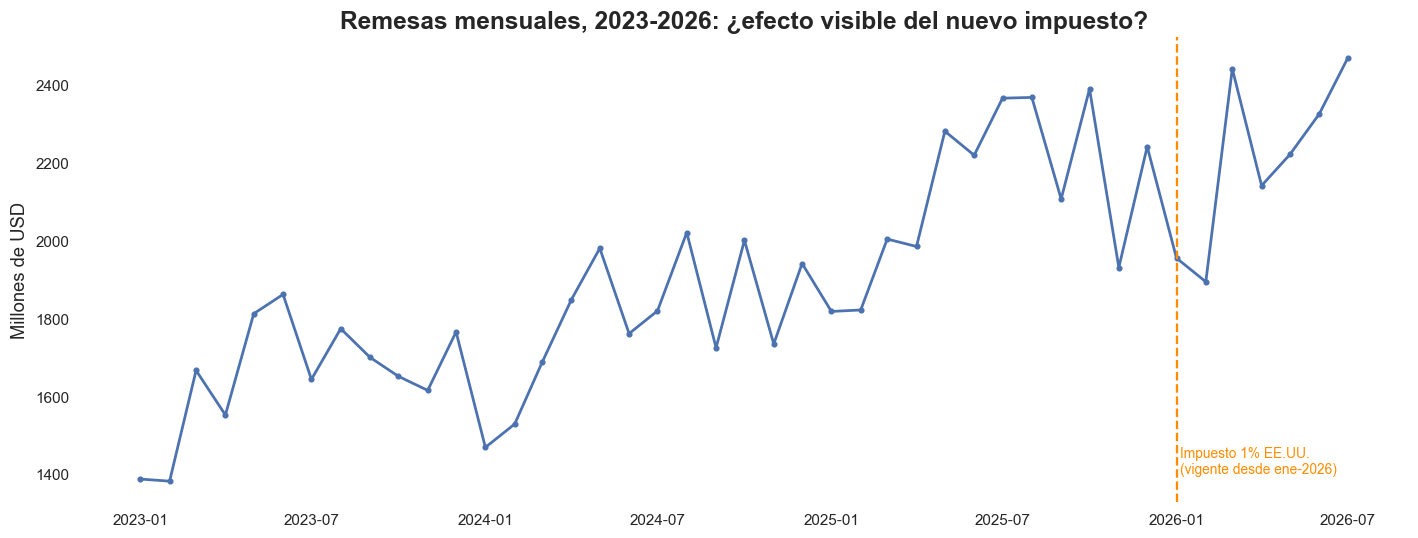

In [75]:
reciente = ingresos_long[ingresos_long["anio"] >= 2023].copy()
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(reciente["fecha"], reciente["monto_millones_usd"], 
        color="#4C72B0", linewidth=1.8, marker="o", markersize=3)

# Línea vertical del impuesto
ax.axvline(pd.Timestamp("2026-01-01"), color="#FF8C00", linestyle="--", linewidth=1.5)
ax.text(pd.Timestamp("2026-01-05"), reciente["monto_millones_usd"].min() + 20, 
        "Impuesto 1% EE.UU.\n(vigente desde ene-2026)", 
        color="#FF8C00", fontsize=9, ha="left")

ax.set_title("Remesas mensuales, 2023-2026: ¿efecto visible del nuevo impuesto?", 
        fontsize=16, fontweight="bold", loc="center")
ax.set_ylabel("Millones de USD", fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()

In [74]:
display(reciente[["fecha", "monto_millones_usd"]])

,fecha,monto_millones_usd
252,2023-01-01,1386.491933
253,2023-02-01,1381.094219
254,2023-03-01,1665.832555
255,2023-04-01,1551.369164
256,2023-05-01,1811.863789
257,2023-06-01,1861.327269
258,2023-07-01,1642.851042
259,2023-08-01,1773.350572
260,2023-09-01,1699.459758
261,2023-10-01,1650.734715


Los montos de 2026 continúan en niveles altos y no se observa una caida inmediata. Para evaluar mejor la desaceleración conviene comparar el crecimiento acumulado del mismo número de meses entre años.

## 11. Comparación enero–julio (YTD)

Como 2026 todavía no está completo, comparar su total contra años completos sería incorrecto. Por eso se usará enero–julio para todos los años y se calculará el crecimiento interanual del mismo periodo.


In [53]:
ytd = ingresos_long[ingresos_long["mes_num"] <= 7].groupby("anio")["monto_millones_usd"].sum().reset_index()
ytd["crecimiento_ytd_pct"] = ytd["monto_millones_usd"].pct_change() * 100

print("Comparación Enero-Julio (year-to-date) por año:")
display(ytd.tail(6))

print(f"\n2026 (ene-jul) vs 2025 (ene-jul): {ytd[ytd['anio']==2026]['crecimiento_ytd_pct'].values[0]:.1f}%")

Comparación Enero-Julio (year-to-date) por año:


,anio,monto_millones_usd,crecimiento_ytd_pct
19,2021,8320.477194,39.629411
20,2022,10081.418041,21.163941
21,2023,11300.829970,12.095639
22,2024,12090.363992,6.986514
23,2025,14493.689495,19.878024
24,2026,15447.121993,6.578259



2026 (ene-jul) vs 2025 (ene-jul): 6.6%


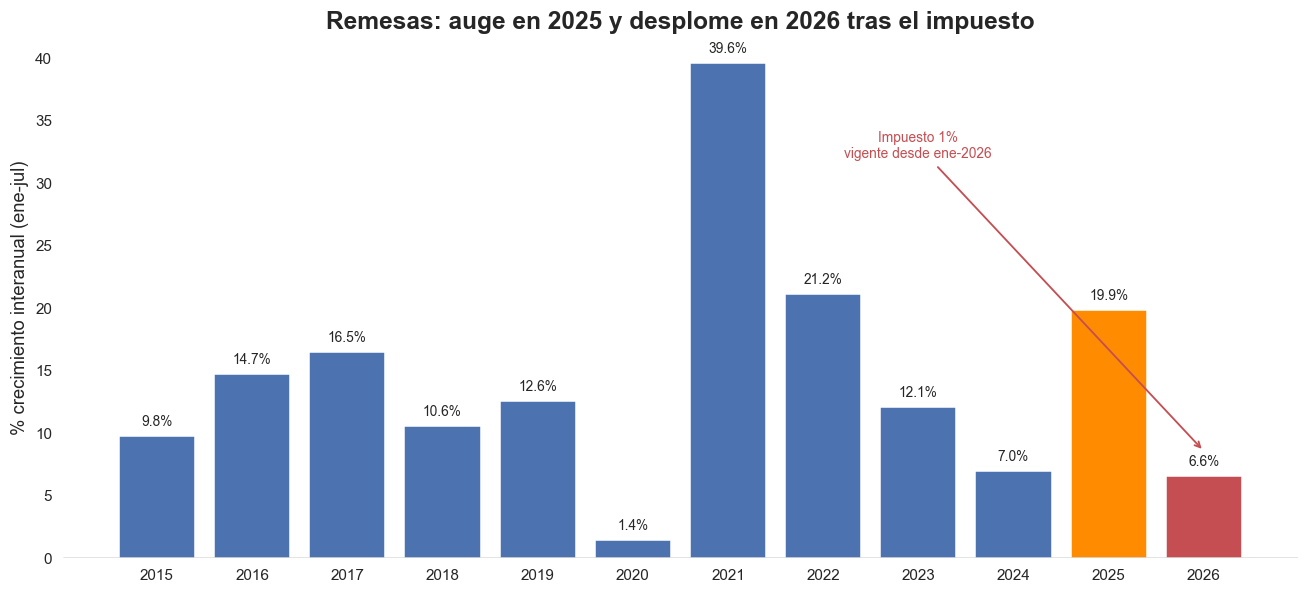

In [ ]:
ytd_plot = ytd[ytd["anio"] >= 2015].copy()
fig, ax = plt.subplots(figsize=(12, 5.5))
colors = ["#C44E52" if a == 2026 else ("#FF8C00" if a == 2025 else "#4C72B0") 
        for a in ytd_plot["anio"]]

bars = ax.bar(ytd_plot["anio"].astype(str), ytd_plot["crecimiento_ytd_pct"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)

ax.set_title("Remesas: auge en 2025 y desplome en 2026 tras el impuesto", 
        fontsize=16, fontweight="bold", loc="center")
ax.set_ylabel("% crecimiento interanual (ene-jul)", fontsize=12)

for bar, val in zip(bars, ytd_plot["crecimiento_ytd_pct"]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.8, f"{val:.1f}%", 
        ha="center", fontsize=9)

ax.annotate("Impuesto 1%\nvigente desde ene-2026", 
        xy=(len(ytd_plot)-1, ytd_plot["crecimiento_ytd_pct"].iloc[-1] + 2), 
        xytext=(len(ytd_plot)-4, 32),                                       
        arrowprops=dict(arrowstyle="->", color="#C44E52", linewidth=1.2),
        color="#C44E52", fontsize=9, ha="center")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()

Entre enero y julio de 2026 las remesas crecieron **6.6%** frente al mismo periodo de 2025, después de crecer **19.9%** en enero–julio de 2025. Hay una desaceleración clara, pero la coincidencia con el impuesto no basta para decir que el impuesto la causó.

## 12. ¿La variación de 2026 sale de lo normal?

Para complementar la comparación YTD se revisa la variación mes a mes desde 2022. La idea es ver si 2026 presenta una volatilidad completamente distinta a la observada antes del impuesto.


In [55]:
serie_reciente = ingresos_long[ingresos_long["anio"] >= 2022].copy().reset_index(drop=True)
serie_reciente["var_mensual_pct"] = serie_reciente["monto_millones_usd"].pct_change() * 100

print("Volatilidad mes-a-mes (2022-2025, antes del impuesto):")
pre_impuesto = serie_reciente[serie_reciente["fecha"] < "2026-01-01"]["var_mensual_pct"]
print(f"  Media: {pre_impuesto.mean():.2f}% | Desv. estándar: {pre_impuesto.std():.2f}%")

print("\nVolatilidad mes-a-mes (2026, con impuesto vigente):")
post_impuesto = serie_reciente[serie_reciente["fecha"] >= "2026-01-01"]["var_mensual_pct"]
print(f"  Media: {post_impuesto.mean():.2f}% | Desv. estándar: {post_impuesto.std():.2f}%")

display(serie_reciente[serie_reciente["anio"]==2026][["fecha","monto_millones_usd","var_mensual_pct"]])

Volatilidad mes-a-mes (2022-2025, antes del impuesto):
  Media: 1.96% | Desv. estándar: 10.94%

Volatilidad mes-a-mes (2026, con impuesto vigente):
  Media: 2.19% | Desv. estándar: 14.16%


,fecha,monto_millones_usd,var_mensual_pct
48,2026-01-01,1954.707294,-12.787470
49,2026-02-01,1893.869963,-3.112350
50,2026-03-01,2441.799547,28.931743
51,2026-04-01,2141.177339,-12.311502
52,2026-05-01,2221.436714,3.748376
53,2026-06-01,2325.540615,4.686332
54,2026-07-01,2468.590521,6.151254


La desviación estándar mensual sube de aproximadamente **10.9%** en 2022–2025 a **14.2%** en 2026. Hay más variación, pero con solo siete meses de 2026 todavía es una muestra corta. Esta es como una señal para monitorear, no como evidencia definitiva de un cambio estructural.

## 13. Storyboard SCQA

**Situación.** Guatemala cerró 2025 con un récord de aproximadamente US$25,530 millones en remesas, después de más de dos décadas de crecimiento.

**Complicación.** En enero de 2026 entró en vigencia un impuesto del 1% en Estados Unidos y, al mismo tiempo, el crecimiento enero–julio bajó de 19.9% en 2025 a 6.6% en 2026.

**Pregunta.** ¿Esta desaceleración indica un cambio estructural del mercado o todavía entra dentro de la variación que ha mostrado históricamente la serie?

**Respuesta / Big idea.** **Las remesas siguen creciendo en 2026, a menor ritmo. Todavía no hay evidencia suficiente para atribuir la desaceleración al impuesto.**


## 14. Recomendación

La empresa no debería asumir todavía que el mercado entró en contracción. Se recomienda **monitorear trimestralmente el crecimiento YTD durante los próximos 2–3 trimestres**, manteniendo flexibilidad antes de hacer cambios permanentes en la estrategia.

Asimismo, sí hay una señal histórica más estable que se puede aprovechar desde ahora: la estacionalidad. Los meses de mayor ingreso pueden usarse para reforzar campañas y capacidad operativa, mientras que los meses más débiles pueden servir para acciones de captación o retención.


## 15. Guardar tablas procesadas


In [56]:
ingresos_long.to_csv("ingresos_long_clean.csv", index=False)
variaciones_long.to_csv("variaciones_long_clean.csv", index=False)
anual.to_csv("anual_clean.csv", index=False)
ytd.to_csv("ytd_clean.csv", index=False)
estacional.to_csv("estacional_clean.csv", index=False)

print("Datasets limpios guardados. Listos para las gráficas finales pulidas.")

Datasets limpios guardados. Listos para las gráficas finales pulidas.
